# Customer Segmentation: RFM Analysis

## Overview
This notebook performs RFM (Recency, Frequency, Monetary) analysis on the Olist dataset to segment customers based on their purchasing behavior.

## Objectives
1.  **Data Extraction:** Retrieve customer purchase history from the SQLite database.
2.  **RFM Calculation:** Calculate Recency, Frequency, and Monetary values for each customer.
3.  **Scoring:** Assign scores (1-5) to each dimension.
4.  **Segmentation:** Group customers into segments (e.g., Champions, At Risk).

In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

In [9]:
# Connect to the SQLite database (located in Project 1 folder)
db_path = '../Project1 (DA)/olist.db'
conn = sqlite3.connect(db_path)

print(f"Connected to database at: {db_path}")

Connected to database at: ../Project1 (DA)/olist.db


## 1. Data Extraction
We need to join `orders`, `order_items`, and `customers` to get:
-   `customer_unique_id`: To identify unique customers (not just single orders).
-   `order_purchase_timestamp`: To calculate Recency.
-   `order_id`: To calculate Frequency.
-   `price`: To calculate Monetary value.

In [10]:
query = """
SELECT 
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    oi.price
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""

df = pd.read_sql(query, conn)

# Convert timestamp to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print("Data loaded successfully!")
print(f"Total rows: {len(df):,}")
display(df.head())

Data loaded successfully!
Total rows: 110,197


,customer_unique_id,order_id,order_purchase_timestamp,price
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90


## 2. RFM Calculation
-   **Recency:** Days since last purchase (relative to the max date in the dataset).
-   **Frequency:** Total number of unique orders.
-   **Monetary:** Total spend.

In [11]:
# Define the reference date (1 day after the last purchase in the dataset)
max_date = df['order_purchase_timestamp'].max()
ref_date = max_date + pd.Timedelta(days=1)

print(f"Reference Date for Recency: {ref_date}")

# Calculate RFM metrics
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (ref_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                            # Frequency
    'price': 'sum'                                                    # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"Unique Customers: {len(rfm):,}")
display(rfm.head())

Reference Date for Recency: 2018-08-30 15:00:37
Unique Customers: 93,358


,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


## 3. RFM Scoring
We will assign scores from 1 to 5 for each metric using quintiles.
-   **Recency:** Lower is better (5 = most recent).
-   **Frequency:** Higher is better (5 = most frequent).
-   **Monetary:** Higher is better (5 = highest spend).

In [12]:
# Recency Score (lower is better, so we swap labels)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency Score (higher is better)
# Note: Many customers have only 1 order, so qcut might fail with duplicate edges.
# We use rank(method='first') to handle ties if needed, or just simple cut if distribution is very skewed.
# For Olist, frequency is very skewed (mostly 1). Let's check distribution first.
print(rfm['frequency'].value_counts().head())

# Since frequency is highly skewed (mostly 1), qcut won't work well.
# We'll define custom bins for Frequency: 1, 2, 3, 4, 5+
def get_f_score(x):
    if x == 1: return 1
    if x == 2: return 2
    if x == 3: return 3
    if x == 4: return 4
    return 5

rfm['f_score'] = rfm['frequency'].apply(get_f_score)

# Monetary Score (higher is better)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores (RFM Score)
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

display(rfm.head())

frequency
1    90557
2     2573
3      181
4       28
5        9
Name: count, dtype: int64


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215


## 4. Segmentation
We can map RFM scores to human-readable segments.
A simple segmentation map based on R and F scores:

segment
Hibernating        36228
Recent Users       36224
About to Sleep     18105
Loyal Customers     1691
At Risk              988
Champions            122
Name: count, dtype: int64


/tmp/ipykernel_276411/3422118865.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm, y='segment', order=order, palette='viridis')


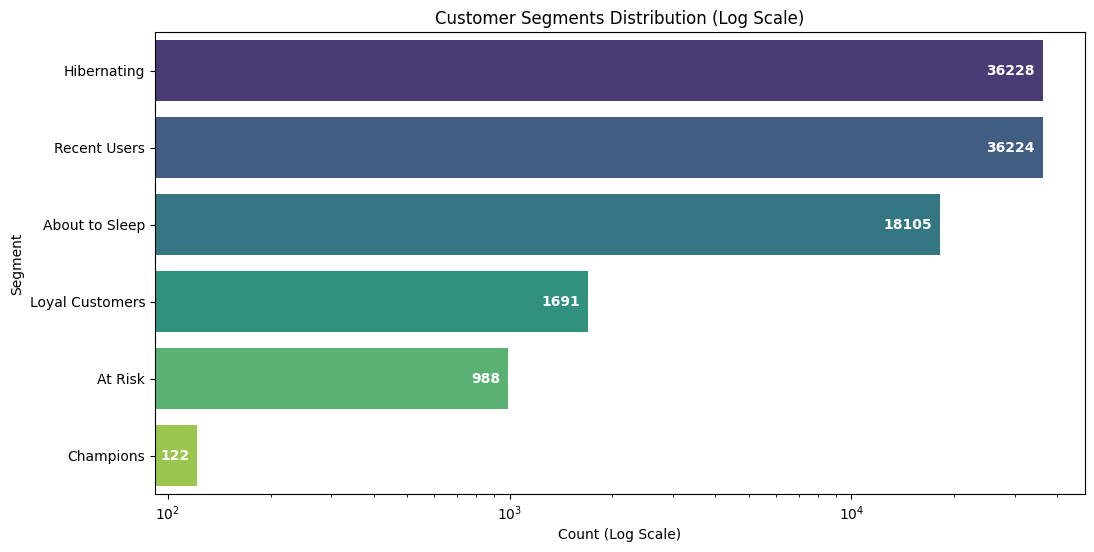

In [13]:
def segment_customer(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    
    if r >= 4 and f >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 4 and f == 1:
        return 'Recent Users'
    elif r == 3 and f == 1:
        return 'About to Sleep'
    elif r <= 2 and f >= 2:
        return 'At Risk'
    elif r <= 2 and f == 1:
        return 'Hibernating'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['segment'].value_counts())

# Visualize Segment Distribution
plt.figure(figsize=(12, 6))
order = rfm['segment'].value_counts().index
ax = sns.countplot(data=rfm, y='segment', order=order, palette='viridis')
plt.title('Customer Segments Distribution (Log Scale)')
plt.xlabel('Count (Log Scale)')
plt.ylabel('Segment')
plt.xscale('log')

# Add labels inside bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Top bars (darker in viridis) get white text, bottom bars (lighter) get black text
    text_color = 'white'
    ax.text(width * 0.95, p.get_y() + p.get_height() / 2, '{:.0f}'.format(width), 
            ha='right', va='center', color=text_color, fontweight='bold')

plt.show()